# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.differentiate import derivative
from scipy.integrate import solve_ivp, quad

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [2]:
G = 6.6743e-11
g_0 = 9.81 
M_e = 5.792e24
M_m = 7.35e22
R_e = 6.378e6
R_m = 1.738e6

In [3]:
a=g_0
#y = .5*a*t**2  #assuming v_0 = 0
# so t= sqrt(2y/a)
y = -4000 # meters
t_num = np.sqrt(2*-y/a)
print(f't = {t_num:0f} seconds')

t = 28.556862 seconds


$\frac{dv}{dt} = -g + \alpha \left| v \right|^{\gamma}$

Text(0.5, 1.0, 'Figure 1')

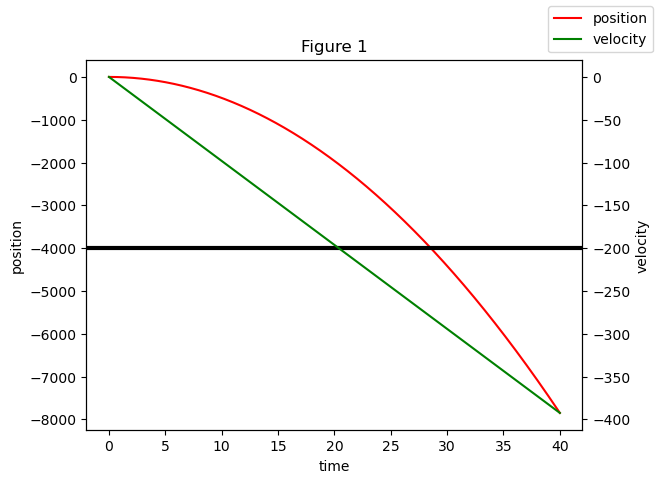

In [4]:
gamma = 1
a = 0
def Derivatives(t,s):
    D = np.zeros(2)
    D[0] = s[1]
    D[1] = -g_0 + a*np.abs(s[1])**gamma
    return D
y0,vy0 = 0,0
nt = 1001
t0 = 0 
t1 = 40
t = np.linspace(t0,t1,nt)
soln = solve_ivp(Derivatives, (t0,t1), [y0,vy0], t_eval=t)
tt = soln.t
pos1 = soln.y[0]
vel1 = soln.y[1]
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(tt,pos1, color='red', label='position')
ax2.plot(tt, vel1, color='green', label='velocity')
ax.set_ylabel("position")
ax2.set_ylabel("velocity")
ax.set_xlabel("time")
ax.axhline(-4000, color='black', lw=3)
#ax.legend(loc='upper left')
#ax2.legend()
fig.legend()
ax.set_title('Figure 1')

crash at t = 28.556862458541293


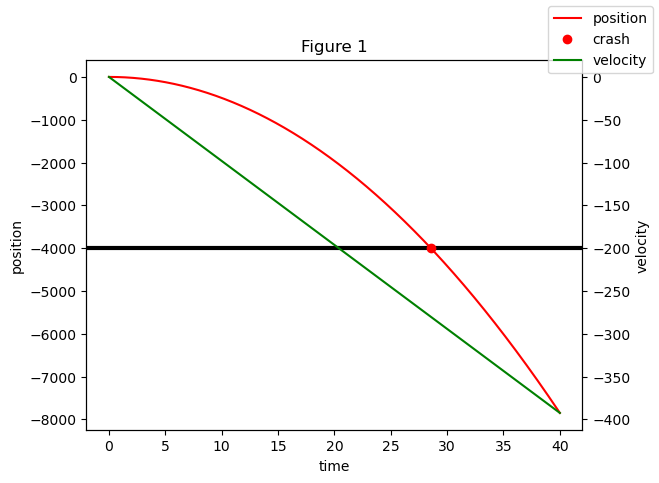

In [5]:
def crash(t, s):
    return s[0]+4000
soln = solve_ivp(Derivatives, (t0,t1), [y0,vy0], t_eval=t,events=crash)
tt = soln.t
pos = soln.y[0]
vel = soln.y[1]
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(tt,pos, color='red', label='position')
ax2.plot(tt, vel, color='green', label='velocity')
ax.set_ylabel("position")
ax2.set_ylabel("velocity")
ax.set_xlabel("time")
ax.axhline(-4000, color='black', lw=3)
#ax.legend(loc='upper left')
#ax2.legend()
ax.set_title('Figure 1')
t_crash = soln.t_events
y_crash = soln.y_events
ax.plot(t_crash, y_crash[0][0][0], 'ro', label='crash')
print(f'crash at t = {t_crash[0][0]}')
fig.legend()

There are no differences between the solve_ivp result and the analytical result.

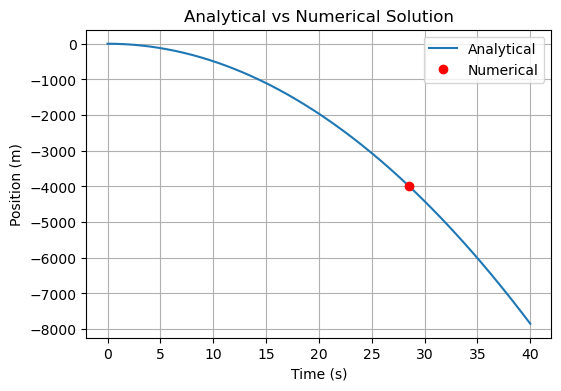

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tt, pos1, label='Analytical')
ax.plot(t_num, y, 'ro', label='Numerical')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('Analytical vs Numerical Solution')
ax.legend()
ax.grid()

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Numerical fall time (variable g + drag): 28.558364503026567
Ideal free fall time: 28.55686245854129
Difference: 0.0015020444852780201


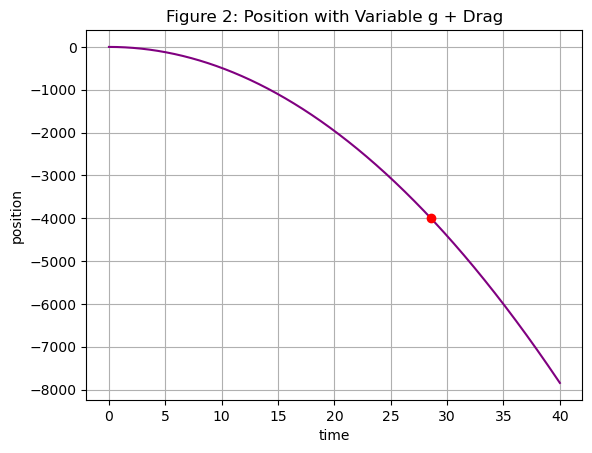

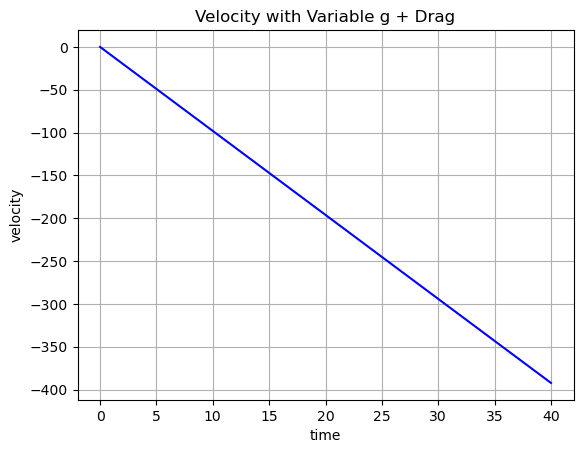

In [7]:
alpha=0
def Derivatives2(t, s):
    y, v = s

    r = R_e - np.abs(y)
    g = g_0 * (r / R_e)

    dvdt = -g - alpha * np.abs(v)**(gamma - 1) * v

    return [v, dvdt]
y0, v0 = 0, 0

t = np.linspace(0, 40, 2000)

soln2 = solve_ivp(Derivatives2, (0, 4000), [y0, v0], t_eval=t)

tt2 = soln2.t
yy2 = soln2.y[0]
vv2 = soln2.y[1]
fig, ax = plt.subplots()
ax.plot(tt2, yy2, color='purple')
ax.set_xlabel("time")
ax.set_ylabel("position")
ax.plot(t_crash[0], y_crash[0][0][0], 'ro', label='crash')
ax.set_title("Figure 2: Position with Variable g + Drag")
ax.grid()
fig, ax = plt.subplots()
ax.plot(tt2, vv2, color='blue')
ax.set_xlabel("time")
ax.set_ylabel("velocity")
ax.set_title("Velocity with Variable g + Drag")
ax.grid()
def hit_bottom(t, s):
    return s[0] + 4000
soln2_event = solve_ivp(
    Derivatives2,
    (0, 4000),
    [y0, v0],
    t_eval=t,
    events=hit_bottom
)
t_hit = soln2_event.t_events[0][0]
print(f"Numerical fall time (variable g + drag): {t_hit}")
t_ideal = np.sqrt(2 * 4000 / g_0)
print(f"Ideal free fall time: {t_ideal}")
print(f"Difference: {t_hit - t_ideal}")

When gravity depends on height, the gravitational acceleration decreases as the object approaches the center of the Earth.
Drag always increases the fall time compared to both constant-g and variable-g cases, because it limits acceleration and reduces the effective velocity over most of the trajectory.

alpha = 0.003924
Fall time with drag: 83.54182942010658


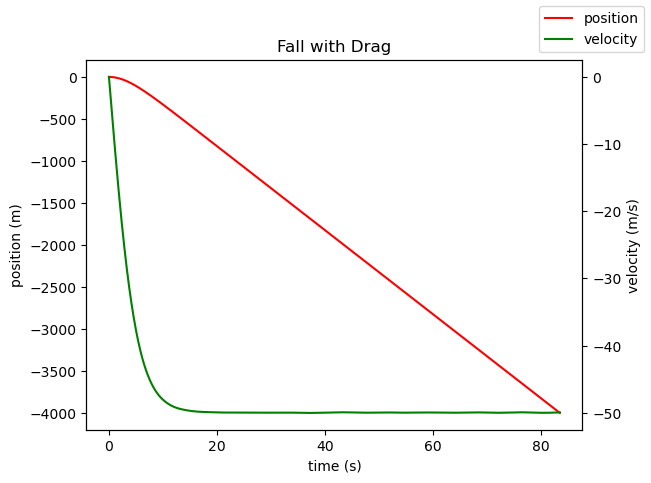

In [8]:
m = 1.0
v_t = 50

alpha = m * g_0 / v_t**2
print("alpha =", alpha)
def fall_drag(t, s):
    y, v = s

    r = R_e - np.abs(y)
    g = g_0 * (r / R_e)

    # quadratic drag opposing motion
    drag = alpha * v * np.abs(v)

    dydt = v
    dvdt = -g - drag

    return [dydt, dvdt]
t_eval = np.linspace(0, 100, 2000)
def hit_bottom(t, s):
    return s[0] + 4000

hit_bottom.terminal = True
hit_bottom.direction = -1
sol_event = solve_ivp(
    fall_drag,
    (0, 4000),
    [0, 0],
    events=hit_bottom,
    t_eval=t_eval
)

print("Fall time with drag:", sol_event.t_events[0][0])

tt = sol_event.t
yy = sol_event.y[0]
vv = sol_event.y[1]
fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(tt, yy, color='red', label='position')
ax2.plot(tt, vv, color='green', label='velocity')

ax.set_xlabel("time (s)")
ax.set_ylabel("position (m)")
ax2.set_ylabel("velocity (m/s)")

ax.set_title("Fall with Drag")

fig.legend()

The drag coefficient was calibrated using the terminal velocity condition:

$$
mg = \alpha v_t^2
$$

so

$$
\alpha = \frac{mg}{v_t^2}
$$

Including drag introduces a velocity-dependent opposing force that reduces acceleration as speed increases.

As a result, the object approaches a terminal velocity and takes longer to reach the bottom of the shaft compared to the no-drag case.

Thus:
- Without drag: motion is approximately uniformly accelerated
- With drag: motion becomes asymptotically velocity-limited, increasing fall time

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




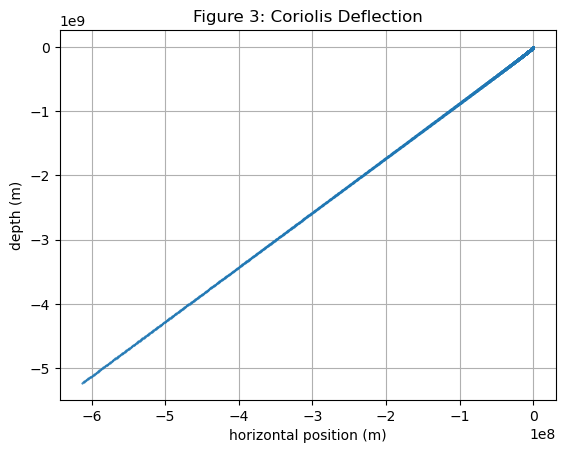

In [9]:
Omega = 7.272e-5
def coriolis_motion(t, s):
    x, y, vx, vy = s

    r = R_e - y
    g = g_0 * (r / R_e)

    dxdt = vx
    dydt = vy

    dvxdt = 2 * Omega * vy
    dvydt = -g - 2 * Omega * vx

    return [dxdt, dydt, dvxdt, dvydt]
x0 = 0
y0 = 0
vx0 = 0
vy0 = 0
t = np.linspace(0, 6000, 5000)

soln3 = solve_ivp(
    coriolis_motion,
    (0, 6000),
    [x0, y0, vx0, vy0],
    t_eval=t
)

x = soln3.y[0]
y = soln3.y[1]
vx = soln3.y[2]
vy = soln3.y[3]
fig, ax = plt.subplots()

ax.plot(x, y, '.', markersize=1)
ax.set_xlabel("horizontal position (m)")
ax.set_ylabel("depth (m)")
ax.set_title("Figure 3: Coriolis Deflection")
ax.grid()

The mass will likely hit the wall before reaching the bottom if the shaft is narrow enough. Drag slightly reduces the sideways deflection because Coriolis force depends on velocity. However, it also increases fall time in the early phase compared to its motion.

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





Period: 5066.261728150601
Time to center: 1266.5654320376502
Crossing time: 2533.1308640753005
v_max is  7910.005 meters/second


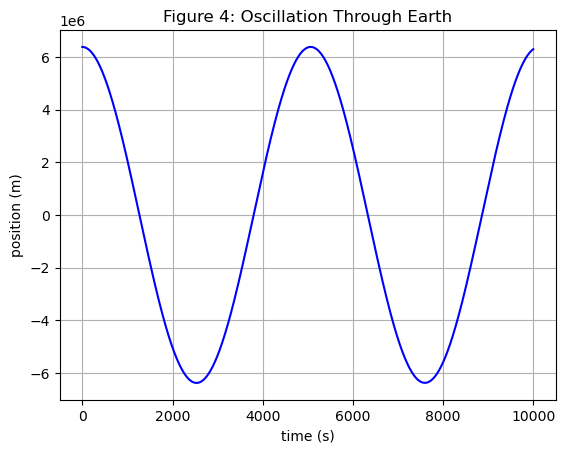

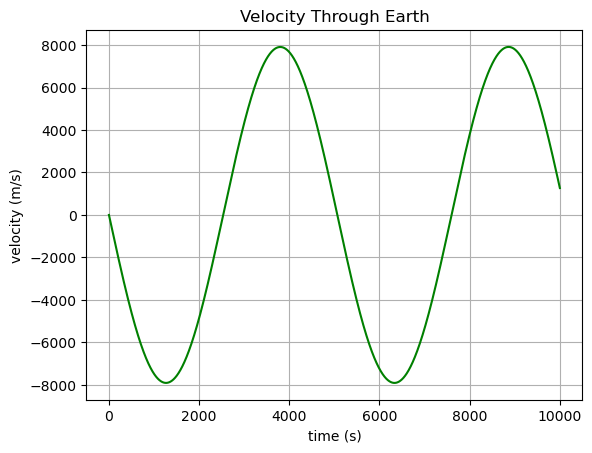

In [10]:
def harmonic_motion(t, s):
    y, v = s

    omega2 = g_0 / R_e

    return [v, -omega2 * y]
t = np.linspace(0, 10000, 10000)

soln4 = solve_ivp(
    harmonic_motion,
    (0, 10000),
    [R_e, 0],
    t_eval=t
)
yy4 = soln4.y[0]
vv4 = soln4.y[1]
fig, ax = plt.subplots()
ax.plot(soln4.t, yy4, color='blue')
ax.set_xlabel("time (s)")
ax.set_ylabel("position (m)")
ax.set_title("Figure 4: Oscillation Through Earth")
ax.grid()

fig, ax = plt.subplots()
ax.plot(soln4.t, vv4, color='green')
ax.set_xlabel("time (s)")
ax.set_ylabel("velocity (m/s)")
ax.set_title("Velocity Through Earth")
ax.grid()

omega = np.sqrt(g_0 / R_e)
T = 2 * np.pi / omega
print("Period:", T)
print("Time to center:", T / 4)
print("Crossing time:", T / 2)
v_max = omega * R_e
print(f'v_max is {v_max: .3f} meters/second')

$$
\ddot{y} = -\omega^2 y
$$
This is simple harmonic motion. The object accelerates through the center slows at the opposite opening of the hole and goes back.

Period of oscillation
$$
T = 2\pi \sqrt{\frac{R_e}{g_0}}
$$
Time to reach the center:
$$
t_{\text{center}} = \frac{T}{4}
$$
Time to reach the other side:
$$
t_{\text{cross}} = \frac{T}{2}
$$

$$
v_{\max} = \sqrt{g_0 R_e}
$$

$$
v_{\text{orb}} = \sqrt{\frac{GM}{R_e}}
$$
Using:
$$
g_0 = \frac{GM}{R_e^2}
$$
we get:
$$
v_{\text{orb}} = \sqrt{g_0 R_e}
$$
So:
$$
v_{\max} \approx v_{\text{orb}}
$$

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

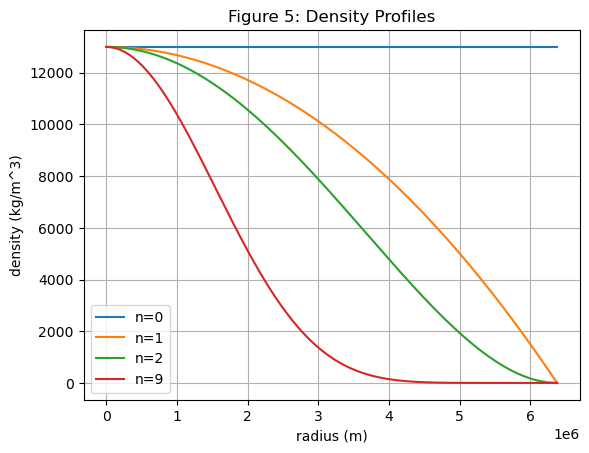

In [11]:
rho0 = 13000 
def density(r, n):
    return rho0 * (1 - (r**2 / R_e**2))**n
r = np.linspace(0, R_e, 1000)

fig, ax = plt.subplots()

for n in [0, 1, 2, 9]:
    ax.plot(r, density(r, n), label=f"n={n}")

ax.set_xlabel("radius (m)")
ax.set_ylabel("density (kg/m^3)")
ax.set_title("Figure 5: Density Profiles")
ax.legend()
ax.grid()

As n increases, density becomes more concentrated near the center, so gravity decreases near surface and increases near the core.

### Part 5, Section B (Forces)

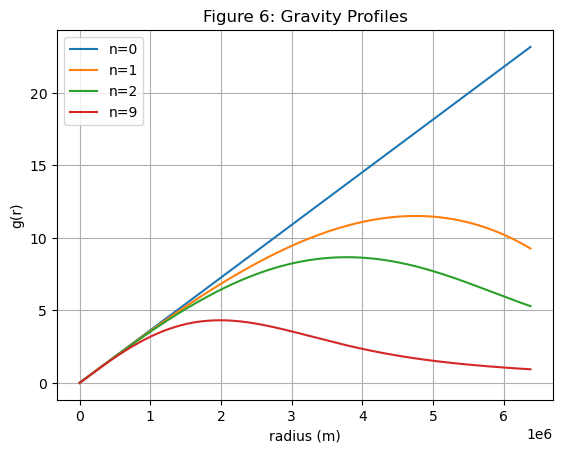

In [12]:
fig, ax = plt.subplots()

for n in [0, 1, 2, 9]:

    g_vals = []

    for ri in r:

        integrand = lambda rp: 4*np.pi * rp**2 * density(rp, n)

        M, _ = quad(integrand, 0, ri)

        g_vals.append(G * M / (ri**2 + 1e-9))

    ax.plot(r, g_vals, label=f"n={n}")

ax.set_xlabel("radius (m)")
ax.set_ylabel("g(r)")
ax.set_title("Figure 6: Gravity Profiles")
ax.legend()
ax.grid()

fall time increases as density becomes more centrally concentrated.

All curves satisfy:

$$
g(R_e)=\frac{GM}{R^2_e}
$$
So they must agree at the surface due to fixed total mass.

### Part 5, Section C (Equations of Motion)

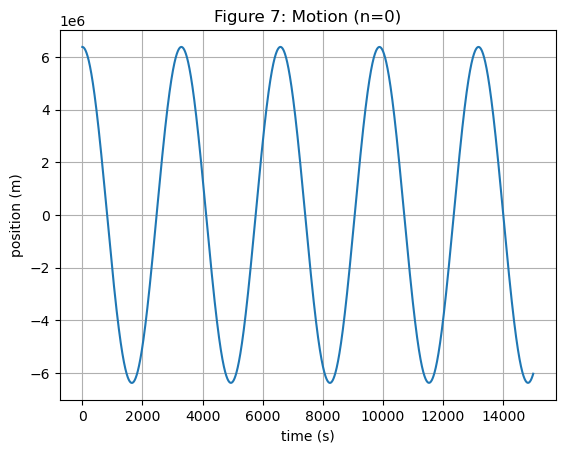

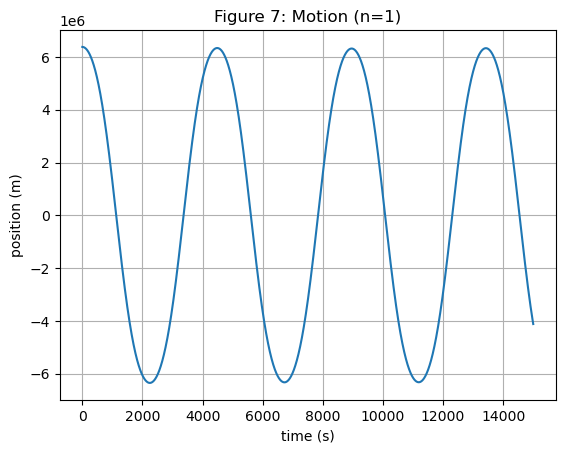

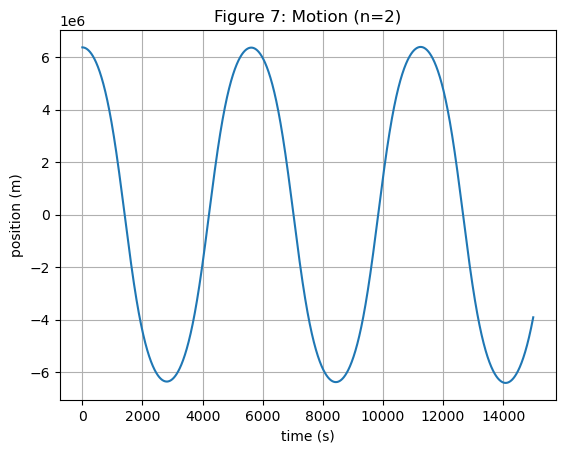

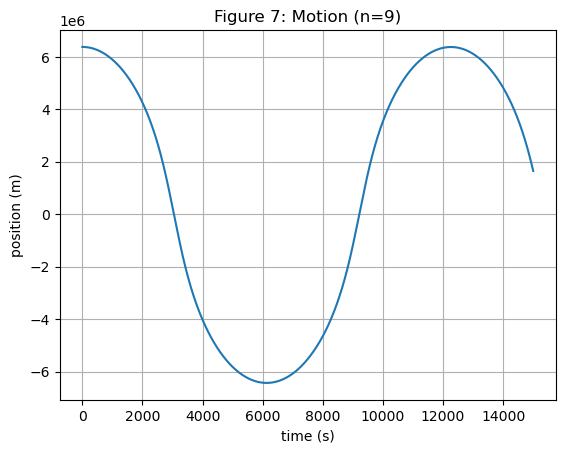

In [13]:
def enclosed_mass(r, n):

    integrand = lambda rp: 4*np.pi * rp**2 * density(rp, n)

    M, _ = quad(integrand, 0, r)

    return M
def orbit_eq(t, s, n):

    y, v = s
    r = abs(y)

    M = enclosed_mass(r, n)
    g = G * M / (r**2 + 1e-9)

    return [v, -np.sign(y) * g]
results = {}

for n in [0, 1, 2, 9]:

    soln = solve_ivp(
        orbit_eq,
        (0, 15000),
        [R_e, 0],
        args=(n,),
        t_eval=np.linspace(0, 15000, 12000)
    )

    results[n] = soln

    fig, ax = plt.subplots()

    ax.plot(soln.t, soln.y[0])

    ax.set_xlabel("time (s)")
    ax.set_ylabel("position (m)")
    ax.set_title(f"Figure 7: Motion (n={n})")
    ax.grid()


central speed increases slightly for higher n, but fall time still increases overall.

In [14]:
def hit_center(t, s):
    return s[0]
hit_center.terminal = True
hit_center.direction = -1
results = {}

for n in [0, 1, 2, 9]:

    sol = solve_ivp(
        lambda t, s: orbit_eq(t, s, n),
        (0, 20000),
        [R_e, 0],
        events=hit_center,
        max_step=5
    )

    results[n] = sol
for n in [0, 1, 2, 9]:

    sol = results[n]

    t_center = sol.t_events[0][0]
    v_center = sol.y_events[0][0][1]

    print(f"n = {n}")
    print(f"  time to center = {t_center:.2f} s")
    print(f"  speed at center = {v_center:.2f} m/s")

n = 0
  time to center = 823.95 s
  speed at center = -12159.15 m/s
n = 1
  time to center = 1127.17 s
  speed at center = -10173.08 m/s
n = 2
  time to center = 1407.56 s
  speed at center = -8958.72 m/s
n = 9
  time to center = 3047.47 s
  speed at center = -5689.16 m/s


The time to reach the center was computed using an event condition in `solve_ivp`, defined by \( y(t) = 0 \), which terminates the integration.

$$
t_c \text{ such that } y(t_c) = 0
$$

The velocity at the center is obtained directly from the numerical solution at the event time:

$$
v_c = v(t_c)
$$

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [15]:
G = 6.6743e-11

M_m = 7.35e22
R_m = 1.738e6

rho_m = M_m / ((4/3)*np.pi*R_m**3)
print("Moon density:", rho_m)

Moon density: 3342.3306645291295


The average density of the Moon is:

$$
\rho_{\text{moon}} = \frac{M_m}{\frac{4}{3}\pi R_m^3} \approx 3340 \; \text{kg/m}^3
$$

The average density of the Earth is:

$$
\rho_{\text{earth}} \approx 5515 \; \text{kg/m}^3
$$

Comparing the two:

$$
\frac{\rho_{\text{moon}}}{\rho_{\text{earth}}} \approx \frac{3340}{5515} \approx 0.61
$$

The Moon is therefore significantly less dense than the Earth, indicating a smaller fraction of heavy elements such as iron in its core and a less differentiated internal structure.

Time to center: 1624.7657641690407
Speed at center: -1679.996960490039


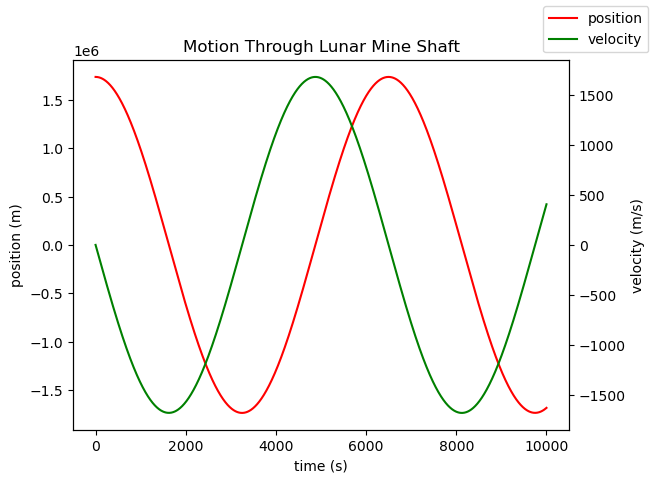

In [16]:
g_m = G * M_m / (R_m**2)

omega_m = np.sqrt(g_m / R_m)
def moon_motion(t, s):
    y, v = s

    g = g_m * (y / R_m)   # linear restoring force

    return [v, -g]
t_eval = np.linspace(0, 10000, 5000)

sol = solve_ivp(
    moon_motion,
    (0, 10000),
    [R_m, 0],
    t_eval=t_eval
)

t = sol.t
y = sol.y[0]
v = sol.y[1]
fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(t, y, label="position", color="red")
ax2.plot(t, v, label="velocity", color="green")

ax.set_xlabel("time (s)")
ax.set_ylabel("position (m)")
ax2.set_ylabel("velocity (m/s)")

ax.set_title("Motion Through Lunar Mine Shaft")

fig.legend()
def hit_center(t, s):
    return s[0]

hit_center.terminal = True
hit_center.direction = -1
sol_event = solve_ivp(
    moon_motion,
    (0, 10000),
    [R_m, 0],
    events=hit_center,
    t_eval=t_eval
)

t_center = sol_event.t_events[0][0]
v_center = sol_event.y_events[0][0][1]

print("Time to center:", t_center)
print("Speed at center:", v_center)

The Moon can be approximated as a constant density sphere, giving a linear gravitational field inside:

$$
g(r) = g_0 \frac{r}{R}
$$

This produces simple harmonic motion:

$$
\frac{d^2 y}{dt^2} = -\omega^2 y
$$

where:

$$
\omega = \sqrt{\frac{g}{R}}
$$

The oscillation period is:

$$
T = 2\pi \sqrt{\frac{R}{g}}
$$

so the time to reach the center is:

$$
t_{\text{center}} = \frac{T}{4}
$$

For a uniform density body:

$$
\omega = \sqrt{\frac{4\pi G \rho}{3}}
$$

so:

$$
T \propto \frac{1}{\sqrt{\rho}}
$$

and therefore:

$$
t_{\text{center}} \propto \rho^{-1/2}
$$

Denser planets produce shorter fall times due to stronger gravitational restoring forces.

## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

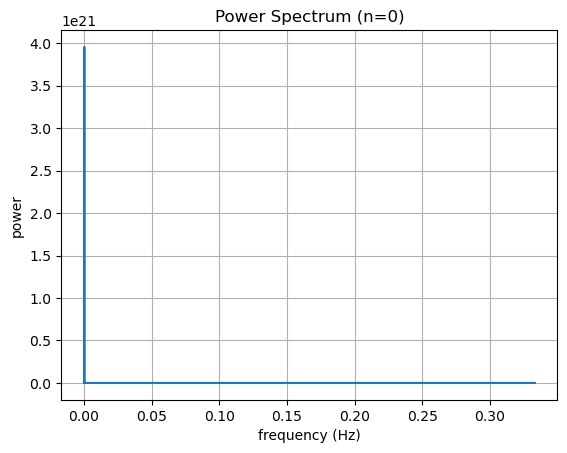

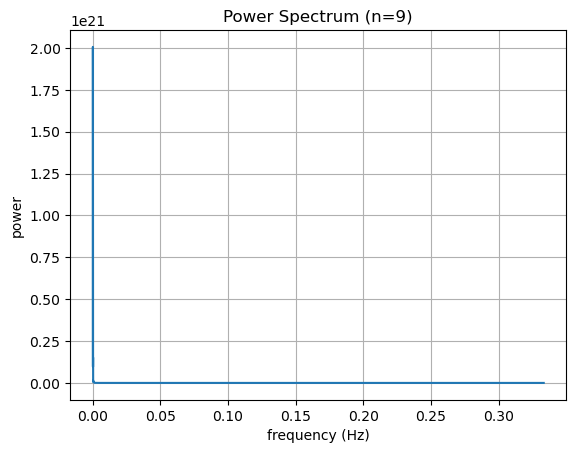

In [17]:
t_eval = np.linspace(0, 30000, 20000)
sol_n0 = solve_ivp(lambda t, s: orbit_eq(t, s, 0),
                   (0, 30000),
                   [R_e, 0],
                   t_eval=t_eval)

sol_n9 = solve_ivp(lambda t, s: orbit_eq(t, s, 9),
                   (0, 30000),
                   [R_e, 0],
                   t_eval=t_eval)
y0 = sol_n0.y[0]
t0 = sol_n0.t
dt0 = t0[1] - t0[0]
F0 = np.fft.fft(y0)
freq0 = np.fft.fftfreq(len(y0), dt0)
power0 = np.abs(F0)**2
mask0 = freq0 > 0

fig, ax = plt.subplots()
ax.plot(freq0[mask0], power0[mask0])
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("power")
ax.set_title("Power Spectrum (n=0)")
ax.grid()


y9 = sol_n9.y[0]
t9 = sol_n9.t
dt9 = t9[1] - t9[0]
F9 = np.fft.fft(y9)
freq9 = np.fft.fftfreq(len(y9), dt9)
power9 = np.abs(F9)**2
mask9 = freq9 > 0

fig, ax = plt.subplots()
ax.plot(freq9[mask9], power9[mask9])
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("power")
ax.set_title("Power Spectrum (n=9)")
ax.grid()

In [18]:
peak0 = freq0[mask0][np.argmax(power0[mask0])]
peak9 = freq9[mask9][np.argmax(power9[mask9])]

print(f"Dominant frequency (n=0): {peak0:.6e} Hz")
print(f"Dominant frequency (n=9): {peak9:.6e} Hz")

Dominant frequency (n=0): 2.999850e-04 Hz
Dominant frequency (n=9): 6.666333e-05 Hz


The position data was transformed using the discrete Fourier transform via `np.fft.fft`.

For \(n = 0\), the motion is approximately simple harmonic, so the power spectrum contains a single dominant frequency peak corresponding to the natural oscillation frequency.

For \(n = 9\), the density profile introduces anharmonicity in the restoring force, causing the motion to deviate from pure sinusoidal behavior. This results in a broadened frequency spectrum with reduced dominance of a single frequency.


The n=0 case behaves very close to simple harmonic motion, so the Fourier transform contains one dominant frequency peak
The n=9 case shows a broader spectrum because the density profile changes the restoring force as the object moves through the Earth
